In [30]:
import warnings
warnings.simplefilter('ignore')

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly
import plotly.graph_objs as go

init_notebook_mode(connected=True)

from sklearn.metrics import mean_squared_error as mse
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
from datetime import datetime, timedelta

In [31]:
df = pd.read_csv('Final_point_1_all_depths.csv')
df.date = pd.to_datetime(df.date)
df = df.groupby(['date', 'depth'])[['temp']].mean()
df = df.reset_index()
df = df.sort_values(by='date')

l = df.date.unique()
l = [x for x in l if (df[df.date == x].depth.max() >= 200) and (df[df.date == x].depth.min() == 0)]
l = sorted(l)

In [32]:
#График зависимости сезонного фактора от года (сезонный фактор -
#это разность температур на нулевой глубине и на максимальной измеренной глубине Байкала)

coeffs = {}
for i in l:
    df1 = df[df.date == i]
    t = np.array(df1.temp)
    d = np.array(df1.depth)
    d_max = max(d)
    t_max = df1[df1.depth == d_max].temp.to_list()[0]
    t_min = df1[df1.depth == 0].temp.to_list()[0]
    coeffs[i] = t_min - t_max

df_new = pd.DataFrame(list(zip(coeffs.keys(), coeffs.values())), columns =['date', 'coeff'])
df_new['num'] = df_new.date.apply(lambda x: (x - datetime(1970, 1, 1)).days)

tr = go.Scatter(
    x=df_new.date,
    y=df_new.coeff,
    mode='markers',
    marker=dict(size=8, color='black'),
    name='_'
)

fig = go.Figure(data=[tr])

fig.update_layout(
    title='Сезонный фактор f (разность температур на нулевой и на максимальной измеренной глубине)',
    xaxis_title='Дата',
    yaxis_title='Сезонный фактор f, °C',
    xaxis_type='date'
)
plotly.offline.plot(fig, filename='_.html', show_link=False)

'_.html'

In [33]:
#График зависимости сезонного фактора от года (сезонный фактор -
#это разность температур на нулевой глубине и на максимальной измеренной глубине Байкала)
#Здесь добавлены точки, которые соответствуют сезонному фактору = 0. Это означает смену теплого и холодного сезона

df = df_new.copy()
traces = []
l = []
for y in range(1948, 2024):
    for i in range(0, 2):
        if i == 0:
            df1 = df[(df.date.dt.year == y) & ((df.date.dt.month >= 5) & (df.date.dt.month <= 6))]
        else:
            df1 = df[((df.date.dt.year == y) & (df.date.dt.month >= 11) & (df.date.dt.month <= 12))]
        ###
        if len(df1) == 2:
            r = []
            for index, row in df1.iterrows():
                r.append((row['num'], row['coeff']))
            (x1,y1) = r[0]
            (x2,y2) = r[1]
            slope = (y2 - y1) / (x2 - x1)
            if slope == 0:
                if abs(y1) > 0.5:
                    continue
                x_intercept = np.mean([x1, x2])
                x_i_d = datetime(1970, 1, 1) + timedelta(days=x_intercept)
                if (x_i_d.month in (5,6) and i == 0) or (x_i_d.month in (11,12) and i == 1):
                    l.append(x_i_d)
                    continue
            else:
                intercept = y1 - slope * x1
                x_intercept = -intercept / slope
                x_i_d = datetime(1970, 1, 1) + timedelta(days=x_intercept)
                if (x_i_d.month in (5,6) and i == 0) or (x_i_d.month in (11,12) and i == 1):
                    l.append(x_i_d)
                    continue
        ###
        if len(df1) <= 2:
            continue
        ###
        slope, intercept = np.polyfit(df1.num, df1.coeff, 1)
        x_intercept = -intercept / slope
        x_i_d = datetime(1970, 1, 1) + timedelta(days=x_intercept)
        x_line = np.linspace(min(df1.num), max(df1.num), 100)
        x_line_dates = [datetime(1970, 1, 1) + timedelta(days=x) for x in x_line]
        y_line = slope * x_line + intercept
        
        if (x_i_d.month not in (5,6) and i == 0) or (x_i_d.month not in (11,12) and i == 1):
            if i == 0:
                df1 = df[(df.date.dt.year == y) & ((df.date.dt.month >= 4) & (df.date.dt.month <= 7))]
            else:
                df1 = df[((df.date.dt.year == y) & (df.date.dt.month >= 10) & (df.date.dt.month <= 12)) | ((df.date.dt.year == y+1) & (df.date.dt.month == 1))]
            slope, intercept = np.polyfit(df1.num, df1.coeff, 1)
            x_intercept = -intercept / slope
            x_i_d = datetime(1970, 1, 1) + timedelta(days=x_intercept)
            x_line = np.linspace(min(df1.num), max(df1.num), 100)
            x_line_dates = [datetime(1970, 1, 1) + timedelta(days=x) for x in x_line]
            y_line = slope * x_line + intercept
            if (x_i_d.month not in (4,5,6,7) and i == 0) or (x_i_d.month not in (10,11,12,1) and i == 1) \
            or (x_i_d.year not in (y,y+1)) or (x_i_d.year == y+1 and x_i_d.month != 1):
                continue
        l.append(x_i_d)
        trace = go.Scatter(x=x_line_dates, y=y_line, mode='lines')
        traces.append(trace)


tr = go.Scatter(
    x=df.date,
    y=df.coeff,
    mode='markers',
    marker=dict(size=8, color='black'),
)
traces.append(tr)
tr = go.Scatter(
    x=l,
    y=np.zeros(len(l)),
    mode='markers',
    marker=dict(size=8, color='red'),
)
traces.append(tr)

fig = go.Figure(data=traces)

fig.update_layout(
    title='Сезонный фактор f (разность температур на нулевой и на максимальной измеренной глубине). Точки f = 0 отмечены красным цветом',
    xaxis_title='Дата',
    yaxis_title='Сезонный фактор f, °C',
    xaxis_type='date',
    showlegend=False
)
plotly.offline.plot(fig, filename='Сезонный_фактор.html', show_link=False)

'Сезонный_фактор.html'

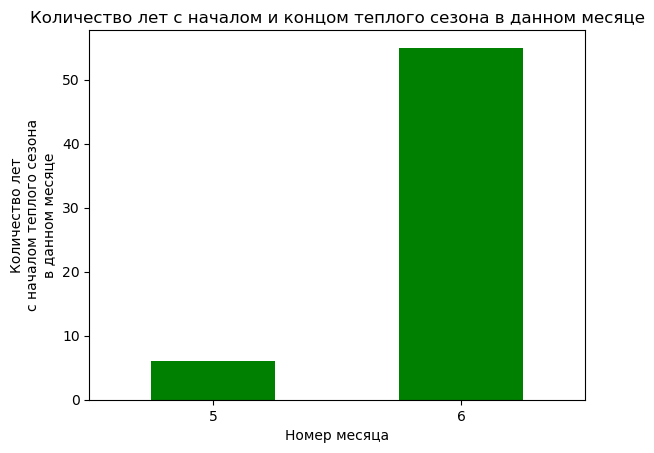

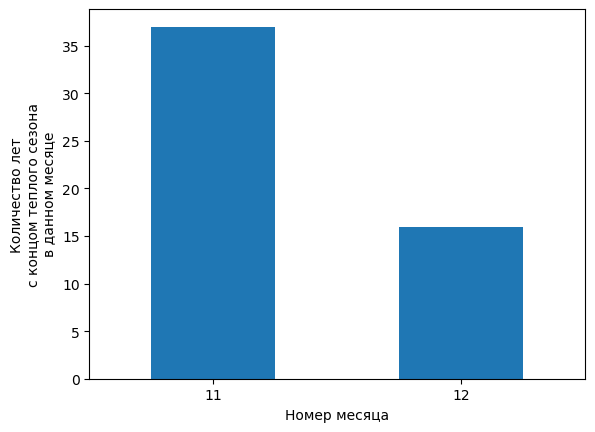

In [34]:
#Количество лет с началом и концом теплого сезона в данном месяце (по горизонтальной оси - номер месяца)

dfqq = pd.DataFrame(l, columns=['date'])
dfqq = dfqq.sort_values(by='date')

fig = dfqq[dfqq.date.dt.month < 8].groupby(dfqq.date.dt.month).count().plot(kind='bar', color='green', rot=0)

plt.ylabel('Количество лет\nс началом теплого сезона\nв данном месяце')
plt.xlabel('Номер месяца')
plt.legend('', frameon=False)
plt.title('Количество лет с началом и концом теплого сезона в данном месяце')
plt.show()

fig = dfqq[dfqq.date.dt.month >= 8].groupby(dfqq.date.dt.month).count().plot(kind='bar', rot=0)

plt.ylabel('Количество лет\nс концом теплого сезона\nв данном месяце')
plt.xlabel('Номер месяца')
plt.legend('', frameon=False)
plt.show()

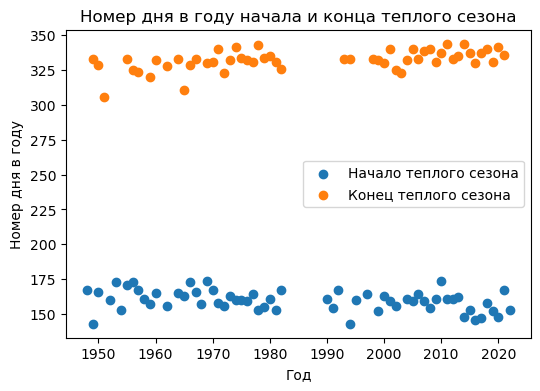

In [35]:
#Номер дня в году начала и конца теплого сезона

fig, ax = plt.subplots(figsize=(6, 4))

df1 = dfqq[(dfqq.date.dt.month >= 4) & (dfqq.date.dt.month <= 7)]
df1 = df1.sort_values(by='date')
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1['year'] = df1.date.apply(lambda x: x.year)
ax.scatter(df1['year'], df1['day'], label='Начало теплого сезона')

df1 = dfqq[(dfqq.date.dt.month >= 10) & (dfqq.date.dt.month <= 12)]
df1 = df1.sort_values(by='date')
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1['year'] = df1.date.apply(lambda x: x.year)
ax.scatter(df1['year'], df1['day'], label='Конец теплого сезона')
ax.set_xlabel('Год')
ax.set_ylabel('Номер дня в году')
plt.legend(loc='best')
plt.title('Номер дня в году начала и конца теплого сезона')
plt.show()

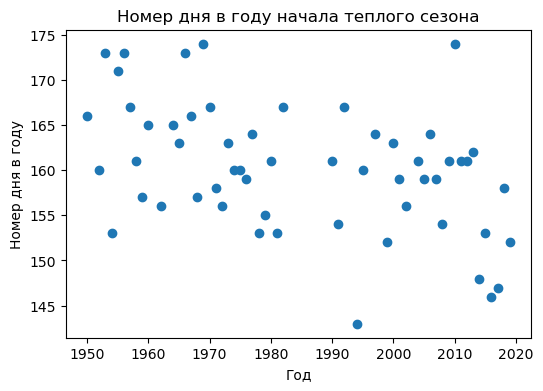

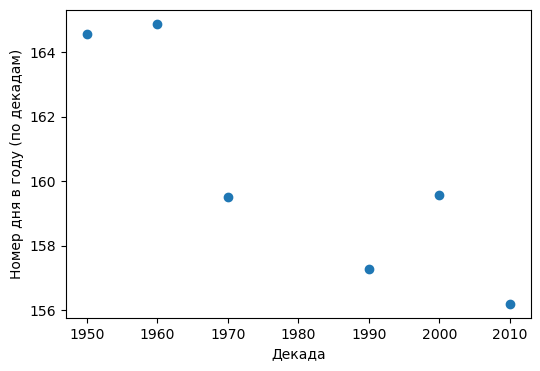

In [19]:
#Номер дня в году начала теплого сезона (на втором графике усреднение по десятилетиям)

fig, ax = plt.subplots(figsize=(6, 4))
df1 = dfqq[(dfqq.date.dt.year >= 1950) & (dfqq.date.dt.month >= 4) & (dfqq.date.dt.month <= 7) & (dfqq.date.dt.year <= 2019)]
df1['year'] = df1.date.apply(lambda x: x.year)
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1 = df1.sort_values('date')
ax.scatter(df1.year, df1.day)
ax.set_xlabel('Год')
ax.set_ylabel('Номер дня в году')
plt.title('Номер дня в году начала теплого сезона')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df1 = dfqq[(dfqq.date.dt.year >= 1950) & (dfqq.date.dt.month >= 4) & (dfqq.date.dt.month <= 7) & (dfqq.date.dt.year <= 2019)]
df1['year'] = df1.date.apply(lambda x: x.year)
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1['decade'] = (df1['year'] // 10) * 10
df1 = df1.sort_values('date')
dfg = df1.groupby('decade')['day'].agg([np.mean, len])
dfg = dfg[dfg.len >= 5]
ax.scatter(dfg.index, dfg['mean'])
ax.set_xlabel('Декада')
ax.set_ylabel('Номер дня в году (по декадам)')
plt.show()

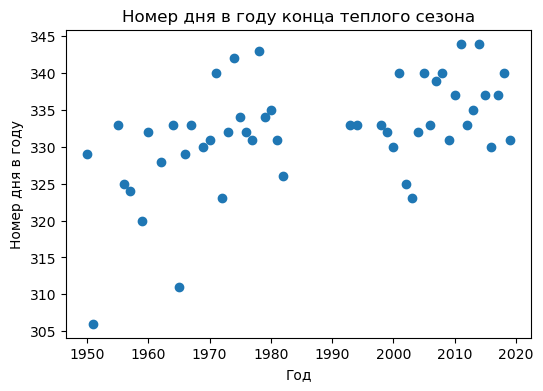

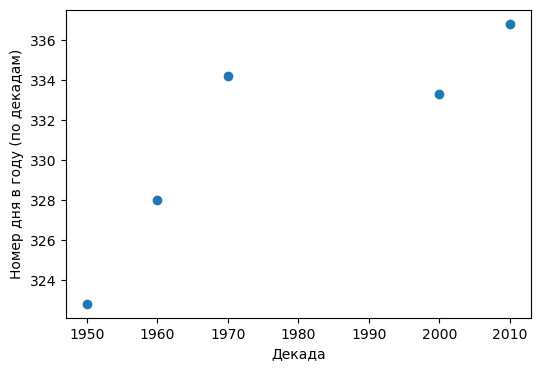

In [18]:
#Номер дня в году конца теплого сезона (на втором графике усреднение по десятилетиям)

fig, ax = plt.subplots(figsize=(6, 4))
df1 = dfqq[(dfqq.date.dt.year >= 1950) & (dfqq.date.dt.month >= 10) & (dfqq.date.dt.month <= 12) & (dfqq.date.dt.year <= 2019)]
df1['year'] = df1.date.apply(lambda x: x.year)
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1 = df1.sort_values('date')
ax.scatter(df1.year, df1.day)
ax.set_xlabel('Год')
ax.set_ylabel('Номер дня в году')
plt.title('Номер дня в году конца теплого сезона')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
df1 = dfqq[(dfqq.date.dt.year >= 1950) & (dfqq.date.dt.month >= 10) & (dfqq.date.dt.month <= 12) & (dfqq.date.dt.year <= 2019)]
df1['year'] = df1.date.apply(lambda x: x.year)
df1['day'] = df1.date.apply(lambda x: x.dayofyear)
df1['decade'] = (df1['year'] // 10) * 10
df1 = df1.sort_values('date')
dfg = df1.groupby('decade')['day'].agg([np.mean, len])
dfg = dfg[dfg.len >= 5]
ax.scatter(dfg.index, dfg['mean'])
ax.set_xlabel('Декада')
ax.set_ylabel('Номер дня в году (по декадам)')
plt.show()

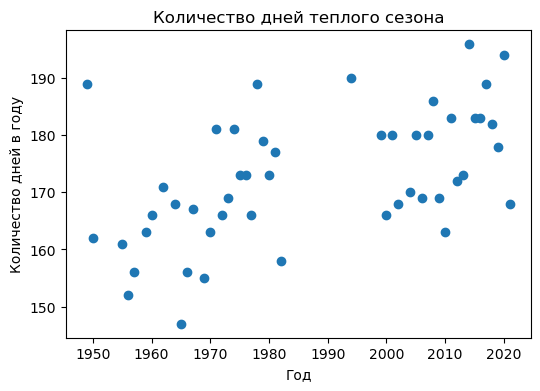

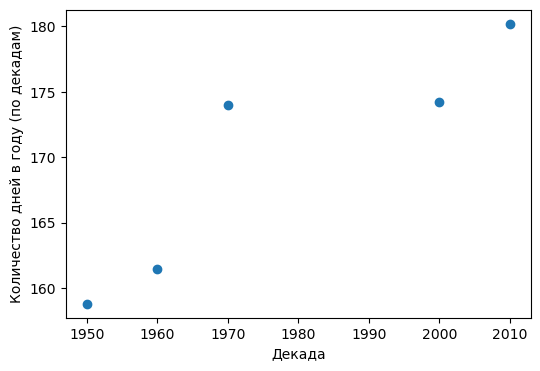

In [17]:
#Количество дней теплого сезона по годам (на втором графике усреднение по десятилетиям)

from itertools import product

joined_df = pd.DataFrame(list(product(dfqq['date'], dfqq['date'])), columns=['date_left', 'date_right'])
joined_df = joined_df[(joined_df.date_left.dt.year == joined_df.date_right.dt.year)]
joined_df = joined_df[(joined_df.date_left.dt.month >= 4) & (joined_df.date_left.dt.month <= 7)]
joined_df = joined_df[(joined_df.date_right.dt.month >= 10) & (joined_df.date_right.dt.month <= 12)]
joined_df['days_diff'] = (joined_df.date_right - joined_df.date_left).dt.days
joined_df['year'] = joined_df.date_right.apply(lambda x: x.year)
joined_df = joined_df.sort_values('year')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(joined_df.year, joined_df.days_diff)
ax.set_xlabel('Год')
ax.set_ylabel('Количество дней в году')
plt.title('Количество дней теплого сезона')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
joined_df = joined_df[(joined_df.year >= 1950) & (joined_df.year <= 2019)]
joined_df['decade'] = (joined_df['year'] // 10) * 10
dfg = joined_df.groupby('decade')['days_diff'].agg([np.mean, len])
dfg = dfg[dfg.len >= 4]
ax.scatter(dfg.index, dfg['mean'])
ax.set_xlabel('Декада')
ax.set_ylabel('Количество дней в году (по декадам)')
plt.show()